In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [24]:
# 1. Загружаем данные (знаменитый MNIST - рукописные цифры)
# Преобразуем изображения в тензоры и нормализуем их в диапазон [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Создаём загрузчики для обучения и тестирования
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)  # Меньший batch для визуализации

In [25]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_log_var = nn.Linear(400, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def decode(self, z):
        reconstruction = self.decoder(z)
        return reconstruction
    
    def forward(self, x):
        x_flat = x.view(-1, 784)
        mu, log_var = self.encode(x_flat)
        z = self.reparameterize(mu, log_var)
        reconstructed = self.decode(z)
        return reconstructed, mu, log_var

In [26]:
def loss_function(recon_x, x, mu, log_var):
    """Вычисляем ELBO = Reconstruction Loss + KL Divergence."""
    # Reconstruction Loss (бинарная кросс-энтропия, т.к. пиксели в [0,1])
    # Мы хотим, чтобы recon_x был как можно ближе к исходному x
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # KL Divergence Loss (формула из теории)
    # sum(1 + log_var - mu^2 - exp(log_var))
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # Суммируем и усредняем по батчу (часто делают, но можно и sum)
    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss

In [27]:
latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5  # Можно увеличить для лучшего качества

print("Начинаем обучение VAE...")
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_recon_loss = 0
    train_kl_loss = 0
    
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        
        optimizer.zero_grad()
        recon_batch, mu, log_var = model(data)
        loss, recon_loss, kl_loss = loss_function(recon_batch, data, mu, log_var)
        
        loss.backward()
        train_loss += loss.item()
        train_recon_loss += recon_loss.item()
        train_kl_loss += kl_loss.item()
        optimizer.step()
    
    # Выводим статистику по эпохе
    avg_loss = train_loss / len(train_loader.dataset)
    avg_recon = train_recon_loss / len(train_loader.dataset)
    avg_kl = train_kl_loss / len(train_loader.dataset)
    print(f'Эпоха {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Recon: {avg_recon:.4f}, KL: {avg_kl:.4f}')

print("Обучение завершено!")

Начинаем обучение VAE...


Эпоха 1/5, Loss: 163.9604, Recon: 148.0882, KL: 15.8722
Эпоха 2/5, Loss: 121.5935, Recon: 99.1971, KL: 22.3964
Эпоха 3/5, Loss: 114.6944, Recon: 90.6970, KL: 23.9975
Эпоха 4/5, Loss: 111.5955, Recon: 87.0457, KL: 24.5499
Эпоха 5/5, Loss: 109.8945, Recon: 85.0614, KL: 24.8331
Обучение завершено!


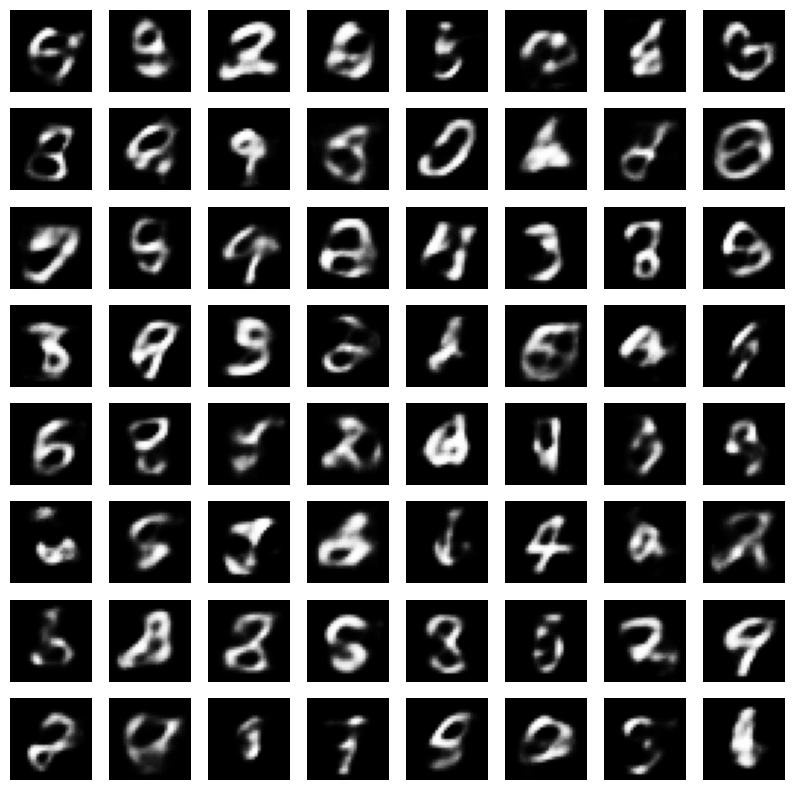

In [28]:
model.eval()  # Переводим модель в режим оценки (отключаем Dropout и т.п.)
with torch.no_grad():  # Отключаем вычисление градиентов для экономии памяти
    # Берём случайный вектор из нормального распределения
    sample_z = torch.randn(64, latent_dim).to(device)  # 64 - сколько цифр сгенерировать
    sample = model.decode(sample_z).cpu()

    # Визуализируем результат
    fig, axes = plt.subplots(8, 8, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        ax.imshow(sample[i].view(28, 28).numpy(), cmap='gray')
        ax.axis('off')
    plt.show()

In [29]:
def visualize_results(model, data_loader, device, num_samples=8, latent_dim=20):
    """
    Визуализирует оригиналы, восстановленные и сгенерированные изображения
    
    Args:
        model: обученная VAE модель
        data_loader: DataLoader с тестовыми данными
        device: устройство (cpu или cuda)
        num_samples: количество примеров для показа
        latent_dim: размерность латентного пространства
    """
    model.eval()
    
    # Часть 1: Получаем оригиналы и восстановленные изображения
    with torch.no_grad():
        # Берём батч данных
        data, _ = next(iter(data_loader))
        data = data[:num_samples].to(device)
        
        # Пропускаем через модель
        reconstructed, mu, log_var = model(data)
        
        # Часть 2: Генерируем новые изображения
        # Случайные векторы из нормального распределения
        z_random = torch.randn(num_samples, latent_dim).to(device)
        generated = model.decode(z_random)
    
    # Подготовка изображений для отображения
    data = data.cpu()
    reconstructed = reconstructed.cpu()
    generated = generated.cpu()
    
    # Создаём фигуру с тремя рядами
    fig, axes = plt.subplots(3, num_samples, figsize=(15, 6))
    
    # Настройка отступов
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    
    # Ряд 1: Оригинальные изображения
    axes[0, 0].set_ylabel('Оригиналы', fontsize=12, rotation=0, labelpad=40)
    for i in range(num_samples):
        axes[0, i].imshow(data[i].view(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Оригинал', fontsize=10)
    
    # Ряд 2: Восстановленные изображения
    axes[1, 0].set_ylabel('Восстановленные', fontsize=12, rotation=0, labelpad=40)
    for i in range(num_samples):
        axes[1, i].imshow(reconstructed[i].view(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Из VAE', fontsize=10)
    
    # Ряд 3: Сгенерированные изображения
    axes[2, 0].set_ylabel('Сгенерированные', fontsize=12, rotation=0, labelpad=40)
    for i in range(num_samples):
        axes[2, i].imshow(generated[i].view(28, 28), cmap='gray')
        axes[2, i].axis('off')
        if i == 0:
            axes[2, i].set_title('Из N(0,1)', fontsize=10)
    
    plt.suptitle('Результаты VAE: Оригиналы vs Восстановленные vs Сгенерированные', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

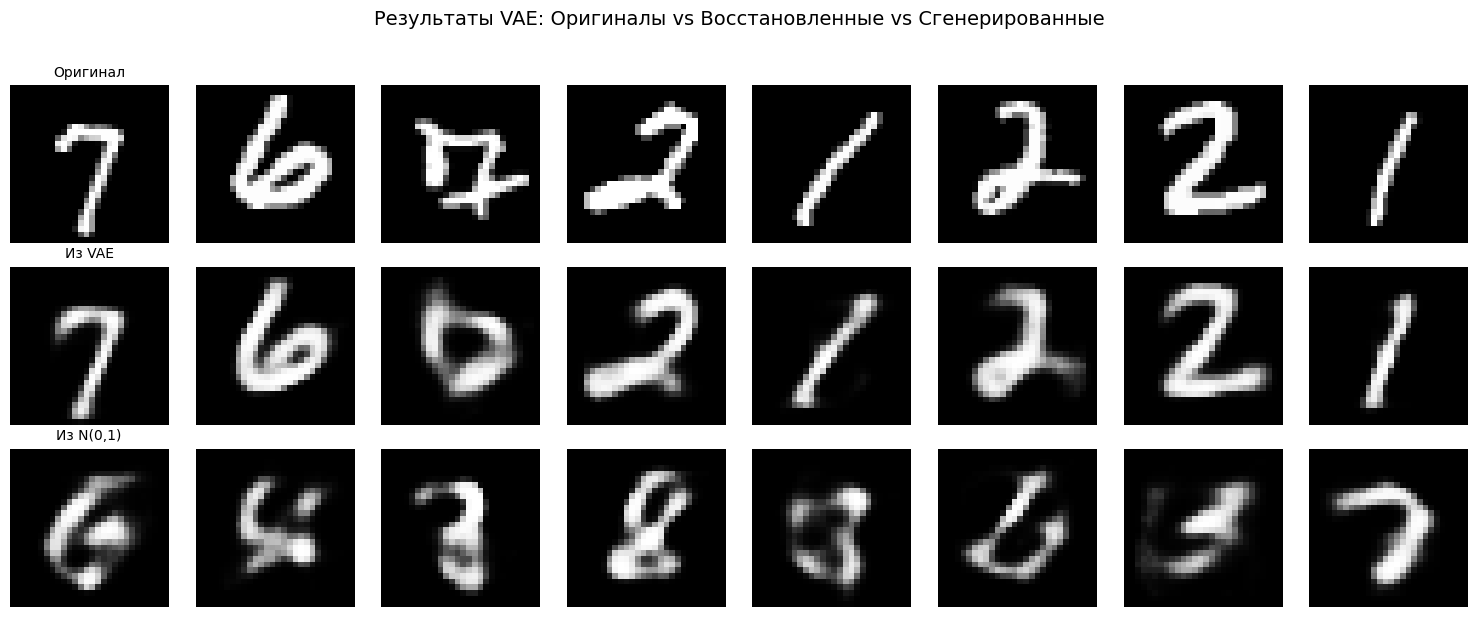

In [30]:
visualize_results(model, test_loader, device, num_samples=8, latent_dim=latent_dim)
